# Comparison: needle-thru-polymerized vs 2-day formalin-fixed decell chicken tissue

Both runs (FORCE + LENGTH) go through the **identical pipeline** used by the per-day notebooks:
align scope to potentiostat -> MAD outlier filter -> map to applied V ->
**global linear-slippage correction** -> final cycle (scan 3, most equilibrated) -> smooth.

- **Needle-thru** (2026-06-22): decell tissue polymerized with the needle threaded through it.
  Geometry 2.7 x 7 x 0.808 mm  (A = 2.182 mm^2, L0 = 7 mm).
- **2-day** (2026-06-15): 2-day 10% formalin-fixed decell tissue from `6.16.26_...`.
  Geometry 2.8 x 9 x 0.45 mm  (A = 1.260 mm^2, L0 = 9 mm).

We compare the final-cycle **stress swing** (MPa, FORCE) and **strain swing** (%, LENGTH),
i.e. the real electro-actuation each tissue delivers.

In [1]:
# Config: the two samples, each with its own folder + geometry.
import os, io, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

NEEDLE_BASE = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.18.26_misc_experiments'
SIX_BASE    = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.16.26_formalin_fixed_decell_chicken_experiments'

SCAN_RATE_V_PER_S    = 0.0025
FORCE_GAIN_MN_PER_V  = 56.7        # 1x gain
LENGTH_COEF_MM_PER_V = -0.4130     # 1x gain
WINDOW, K            = 41, 5.0
V_TOP                = 0.98
SMOOTH_WINDOW, SAVGOL_POLY = 101, 3

# One entry per physical sample. 'base' is the folder its files live in; geometry is inline.
SAMPLES = [
    dict(sid='needle_thru', label='needle-thru', color='#d62728', base=NEEDLE_BASE,
         L0=7.0, W=2.7, T=0.808, zorder=5,        # drawn ON TOP of the 2-day curves
         force_scope ='6.22.26_needle_thru_polymerization_FORCE_scope_log_20260622_133652.csv',
         length_scope='6.22.26_needle_thru_polymerization_LENGTH_scope_log_20260622_150048.csv',
         force_poten ='potentiostat/06.22.26-decell-tissue-with_needl_thru-FORCE-2.5mvperSec.csv',
         length_poten='potentiostat/06.22.26-decell-tissue-with_needl_thru-LENGTH-2.5mvperSec.csv'),
    dict(sid='2_day', label='2-day decell', color='#1f77b4', base=SIX_BASE,
         L0=9.0, W=2.8, T=0.45, zorder=2,
         force_scope ='2day_10%_formalin_fixed_FORCE_scope_log_20260615_134504_2Day_10%_formalin_2.5mVperSecond_FORCE.csv',
         length_scope='2day_10%_formalin_fixed_LENGTHscope_log_20260615_170309_2Day_10%_formalin_2.5mVperSecond_LENGTH.csv',
         force_poten ='potentiostat/06.15.26-2Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         length_poten='potentiostat/06.15.26-2Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
]

In [2]:
# Shared processing -- identical math to the per-day notebooks, but base path is per-sample.
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad = mad.clip(lower=max(np.nanstd(x) * 1e-3, 1e-9))
    return (abs_dev > k * mad).values

def savgol_per_cycle(df, col, window=SMOOTH_WINDOW, poly=SAVGOL_POLY):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp'); y = sub[col].values; n = len(y)
        if n < 3:
            out.loc[sub.index] = y; continue
        w = min(window, n); w -= (w % 2 == 0)
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out

def load_poten(path):
    text = open(path, 'rb').read().decode('utf-16').replace('﻿', '')
    rows = [r for r in csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))) if r and r[0]]
    n = len(rows[0]) // 2
    cols = []
    for s in range(n):
        cols += [f'v{s+1}', f'i{s+1}_uA']
    df = pd.DataFrame([[float(x) for x in r[:2*n]] for r in rows], columns=cols)
    return df, n

def process(base, scope_csv, poten_csv, channel, coef):
    """Returns (poten df, n_scans, slippage-corrected scope df) with v_applied, cycle,
    value_corr (physical units), smooth_corr (savgol). Same as the per-day pipeline."""
    poten, n = load_poten(os.path.join(base, poten_csv))
    v1 = poten['v1'].values; turn = int(np.argmin(v1))
    DT = abs(v1[0] - v1[turn]) / turn / SCAN_RATE_V_PER_S
    per = len(poten) * DT; total = n * per
    t_scan = np.arange(len(poten)) * DT
    t_full = np.concatenate([t_scan + s*per for s in range(n)])
    v_full = np.concatenate([poten[f'v{s+1}'].values for s in range(n)])

    scope = pd.read_csv(os.path.join(base, scope_csv)); scope['t_exp'] = scope['elapsed_s']
    s_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= total)].copy()
    s_in = s_in.loc[~mark_outliers(s_in[channel].values, WINDOW, K)].copy()
    s_in['v_applied'] = np.interp(s_in['t_exp'].values, t_full, v_full)
    s_in['cycle'] = np.clip((s_in['t_exp'].values // per).astype(int), 0, n-1)

    t0 = s_in['t_exp'].min()
    top = s_in[s_in['v_applied'] >= V_TOP]
    b, a = np.polyfit(top['t_exp'].values, top[channel].values, 1)   # linear slippage
    s_in['corrected']  = s_in[channel] - b * (s_in['t_exp'] - t0)
    s_in['value_corr'] = s_in['corrected'] * coef
    s_in['smooth_corr'] = savgol_per_cycle(s_in, 'value_corr')
    return poten, n, s_in

In [3]:
# Process both samples; collect final-cycle stress/strain curves + swing deltas.
records = []
final_stress, final_strain = {}, {}     # sid -> (v_applied, stress_MPa / strain_pct)
final_force_cv, final_length_cv = {}, {} # sid -> (V, I_uA) potentiostat final cycle

for s in SAMPLES:
    sid = s['sid']; area = s['W'] * s['T']; L0 = s['L0']

    pf, nf, sf = process(s['base'], s['force_scope'], s['force_poten'], 'ch2_MEAN_V', FORCE_GAIN_MN_PER_V)
    subf = sf[sf['cycle'] == nf - 1].sort_values('v_applied')
    stress = subf['smooth_corr'] / area / 1000.0       # mN -> MPa
    final_stress[sid]   = (subf['v_applied'].values, stress.values)
    final_force_cv[sid] = (pf[f'v{nf}'].values, pf[f'i{nf}_uA'].values)

    pl, nl, sl = process(s['base'], s['length_scope'], s['length_poten'], 'ch1_MEAN_V', LENGTH_COEF_MM_PER_V)
    subl = sl[sl['cycle'] == nl - 1].sort_values('v_applied')
    strain = subl['smooth_corr'] / L0 * 100.0          # mm -> % strain
    final_strain[sid]    = (subl['v_applied'].values, strain.values)
    final_length_cv[sid] = (pl[f'v{nl}'].values, pl[f'i{nl}_uA'].values)

    records.append(dict(sample=s['label'], area_mm2=round(area, 4), L0_mm=L0,
                        thickness_mm=s['T'],
                        force_delta_mN=float(subf['smooth_corr'].max() - subf['smooth_corr'].min()),
                        stress_delta_MPa=float(stress.max() - stress.min()),
                        dist_delta_mm=float(subl['smooth_corr'].max() - subl['smooth_corr'].min()),
                        strain_delta_pct=float(strain.max() - strain.min())))

summary = pd.DataFrame(records)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('Final-cycle (scan 3) per-sample summary, slippage-corrected:')
summary

Final-cycle (scan 3) per-sample summary, slippage-corrected:


,sample,area_mm2,L0_mm,thickness_mm,force_delta_mN,stress_delta_MPa,dist_delta_mm,strain_delta_pct
0,needle-thru,2.1816,7.0000,0.8080,7.2956,0.0033,0.0187,0.2671
1,2-day decell,1.2600,9.0000,0.4500,23.5770,0.0187,0.0477,0.5298


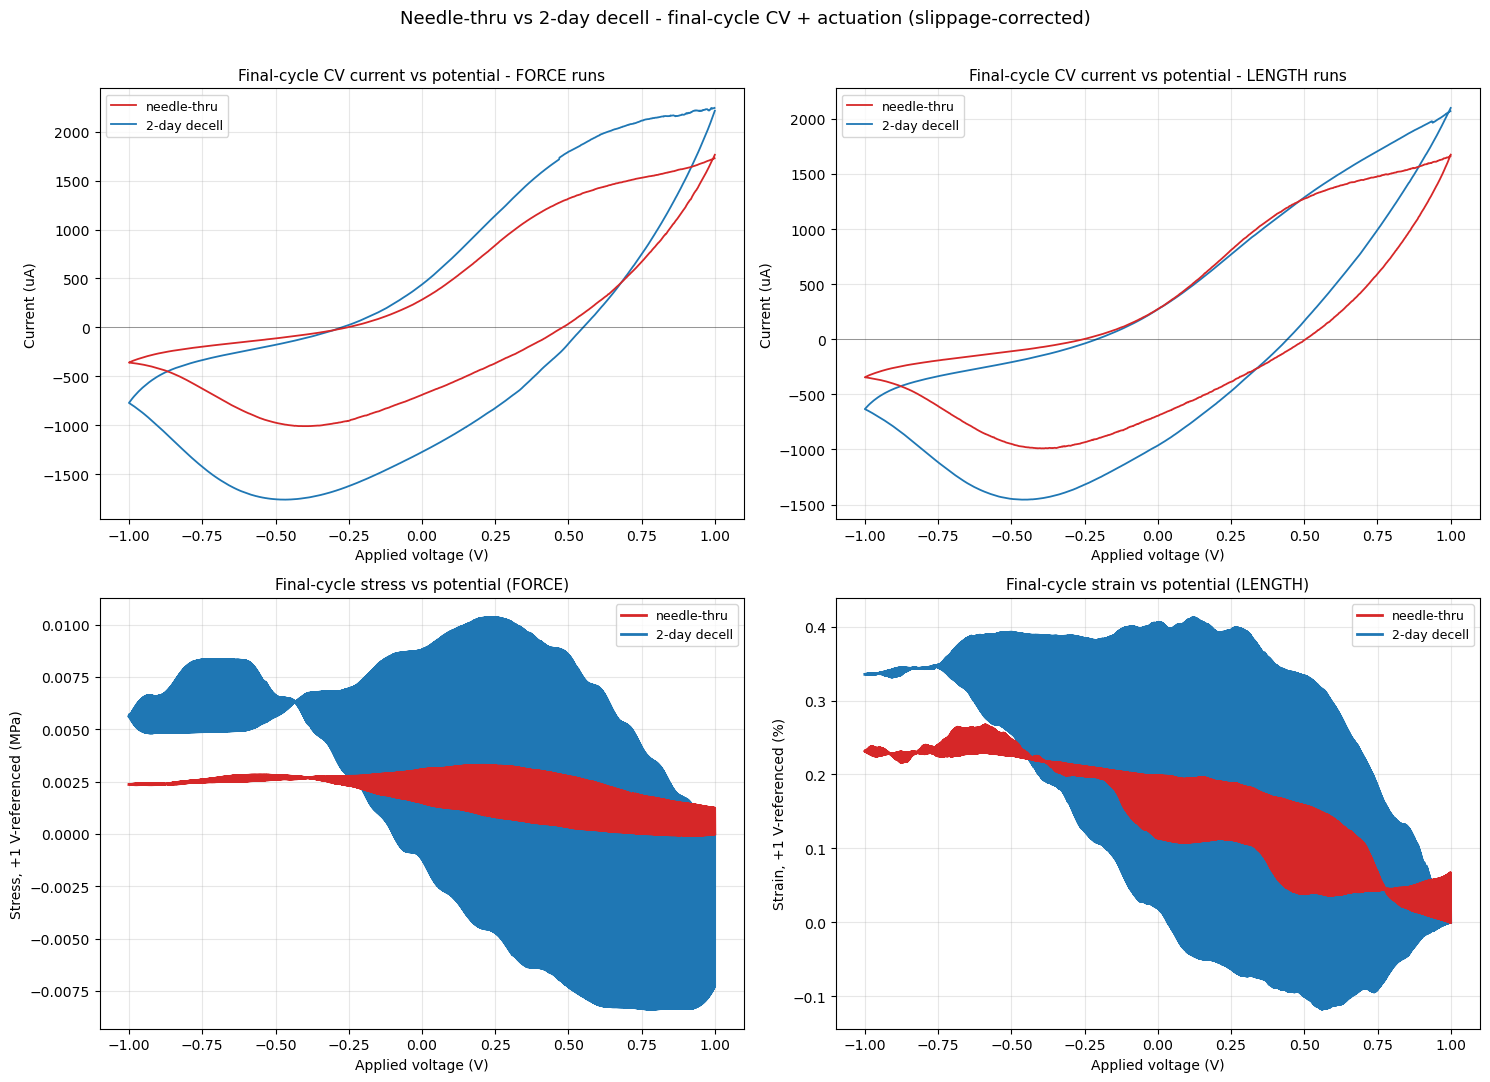

In [4]:
# Final-cycle overlays: potentiostat CV (top), then stress + strain readouts (+1 V-referenced).
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- top row: potentiostat CVs (needle-thru drawn on top via zorder) ---
for s in SAMPLES:
    v, i = final_force_cv[s['sid']];  axes[0, 0].plot(v, i, color=s['color'], lw=1.3, label=s['label'], zorder=s['zorder'])
    v, i = final_length_cv[s['sid']]; axes[0, 1].plot(v, i, color=s['color'], lw=1.3, label=s['label'], zorder=s['zorder'])
for ax, ttl in zip(axes[0], ['FORCE runs', 'LENGTH runs']):
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_xlabel('Applied voltage (V)'); ax.set_ylabel('Current (uA)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.set_title(f'Final-cycle CV current vs potential - {ttl}', fontsize=11)

# --- bottom row: mechanical readouts, each referenced to 0 at +1 V so swings compare ---
for s in SAMPLES:
    v, y = final_stress[s['sid']]; o = np.argsort(v)
    axes[1, 0].plot(v[o], (y - y[np.argmax(v)])[o], color=s['color'], lw=2.0, label=s['label'], zorder=s['zorder'])
    v, y = final_strain[s['sid']]; o = np.argsort(v)
    axes[1, 1].plot(v[o], (y - y[np.argmax(v)])[o], color=s['color'], lw=2.0, label=s['label'], zorder=s['zorder'])
axes[1, 0].set_ylabel('Stress, +1 V-referenced (MPa)')
axes[1, 0].set_title('Final-cycle stress vs potential (FORCE)', fontsize=11)
axes[1, 1].set_ylabel('Strain, +1 V-referenced (%)')
axes[1, 1].set_title('Final-cycle strain vs potential (LENGTH)', fontsize=11)
for ax in axes[1]:
    ax.set_xlabel('Applied voltage (V)'); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

fig.suptitle('Needle-thru vs 2-day decell - final-cycle CV + actuation (slippage-corrected)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

Final-cycle swing (max - min), slippage-corrected:


,sample,area_mm2,L0_mm,thickness_mm,force_delta_mN,stress_delta_MPa,dist_delta_mm,strain_delta_pct
0,needle-thru,2.1816,7.0000,0.8080,7.2956,0.0033,0.0187,0.2671
1,2-day decell,1.2600,9.0000,0.4500,23.5770,0.0187,0.0477,0.5298


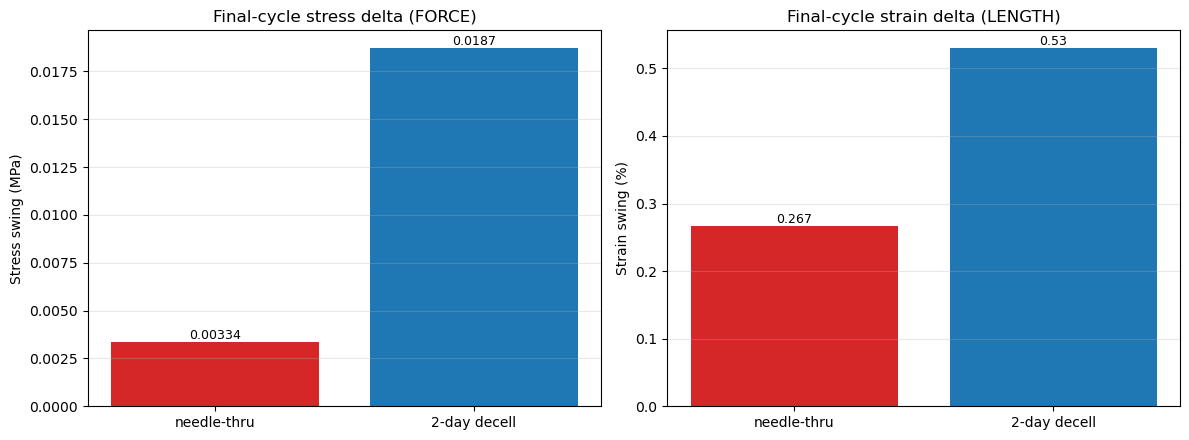


Needle-thru vs 2-day:
  stress swing: 0.0033 vs 0.0187 MPa (0.18x)
  strain swing: 0.2671 vs 0.5298 % (0.50x)
  raw force swing: 7.30 vs 23.58 mN


In [5]:
# Headline: final-cycle swing per sample, side by side.
print('Final-cycle swing (max - min), slippage-corrected:')
display(summary[['sample', 'area_mm2', 'L0_mm', 'thickness_mm',
                 'force_delta_mN', 'stress_delta_MPa', 'dist_delta_mm', 'strain_delta_pct']])

labels = summary['sample'].values
colors = [s['color'] for s in SAMPLES]
xpos = np.arange(len(summary))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(xpos, summary['stress_delta_MPa'], color=colors)
axes[0].set_ylabel('Stress swing (MPa)'); axes[0].set_title('Final-cycle stress delta (FORCE)')
axes[1].bar(xpos, summary['strain_delta_pct'], color=colors)
axes[1].set_ylabel('Strain swing (%)'); axes[1].set_title('Final-cycle strain delta (LENGTH)')
for ax in axes:
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.grid(True, axis='y', alpha=0.3)
    for x, v in zip(xpos, ax.containers[0].datavalues):
        ax.text(x, v, f'{v:.3g}', ha='center', va='bottom', fontsize=9)
fig.tight_layout(); plt.show()

# Ratios (needle-thru / 2-day).
nt = summary[summary['sample'] == 'needle-thru'].iloc[0]
tw = summary[summary['sample'] == '2-day decell'].iloc[0]
print(f"\nNeedle-thru vs 2-day:")
print(f"  stress swing: {nt['stress_delta_MPa']:.4f} vs {tw['stress_delta_MPa']:.4f} MPa "
      f"({nt['stress_delta_MPa']/tw['stress_delta_MPa']:.2f}x)")
print(f"  strain swing: {nt['strain_delta_pct']:.4f} vs {tw['strain_delta_pct']:.4f} % "
      f"({nt['strain_delta_pct']/tw['strain_delta_pct']:.2f}x)")
print(f"  raw force swing: {nt['force_delta_mN']:.2f} vs {tw['force_delta_mN']:.2f} mN")

## Reading the comparison

- **Stress/strain readouts** are referenced to 0 at +1 V, so the curve height directly reads the
  actuation swing each tissue delivers over the cycle.
- **Geometry matters:** needle-thru is thicker (0.808 vs 0.45 mm) and longer (7 vs 9 mm gauge),
  so the same raw force maps to a *lower* stress (larger area) and the same displacement maps to a
  *lower* % strain (longer L0). The delta bars use each sample's own geometry, so they compare the
  intrinsic material response, not just the raw sensor swing.
- Single sample per condition -- treat the ratio as indicative, not statistical. The 6.16.26
  formalin-day comparison notebook is the place to fold this into the broader day-by-day trend once
  replicates exist.